In [4]:
# Import necessary libraries
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from PIL import Image

# Load the dataset
dataset_dir = r'C:\Research\IOU\Dataset_BUSI_with_GT\image'
image_files = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.endswith('.jpg') or f.endswith('.png')]

In [5]:
# Preprocess the images
images = []
for image_file in image_files:
    image = Image.open(image_file)
    image = image.resize((64, 64))  # Resize the images to a common size
    image = np.array(image)
    images.append(image)

images = np.array(images)
images = images.reshape(len(images), -1)  # Flatten the images

In [7]:
# Perform dimensionality reduction using PCA
pcaa = PCA(n_components=50)  # Reduce the dimensionality to 50 features
X_reduced = pcaa.fit_transform(images)

In [8]:
# Perform K-Means clustering
num_clusters = 2  # Set the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_reduced)
labels = kmeans.labels_

C:\Users\sidtu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\sidtu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [16]:
import os
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Set the directory containing the images
image_dir = r"C:\Research\IOU\Dataset_BUSI_with_GT\image"

# Load the new image
image_file = "benign (15).png"  # Replace with the filename of your new image
image_path = os.path.join(image_dir, image_file)
image = Image.open(image_path)
image = image.resize((64, 64))
image_array = np.array(image).reshape(1, -1)

# Define and fit the PCA model
pca = PCA(n_components=50)  # Set the number of components
X_reduced = pca.fit_transform(images)  # Fit the PCA model to the training data

# Perform PCA on the new image
image_pca = pca.transform(image_array)

# Predict the cluster for the new image
cluster = kmeans.predict(image_pca)

print(f"The new image belongs to cluster {cluster[0]}")

The new image belongs to cluster 0


basic working with matplotlib

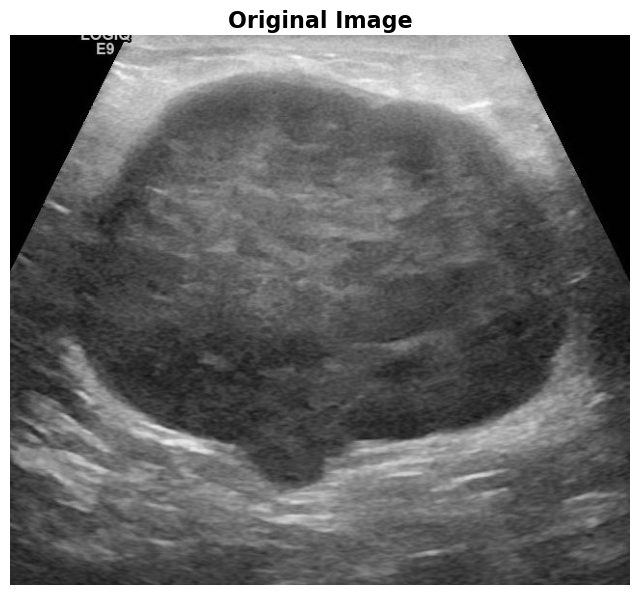

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load the image
image_path = r"C:\Research\IOU\Dataset_BUSI_with_GT\image\malignant (163).png"
image = Image.open(image_path)

# Convert the image to a numpy array
image_array = np.array(image)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(image_array)
plt.title('Original Image', fontsize=16, fontweight='bold', loc='center')
plt.axis('off')
plt.show()

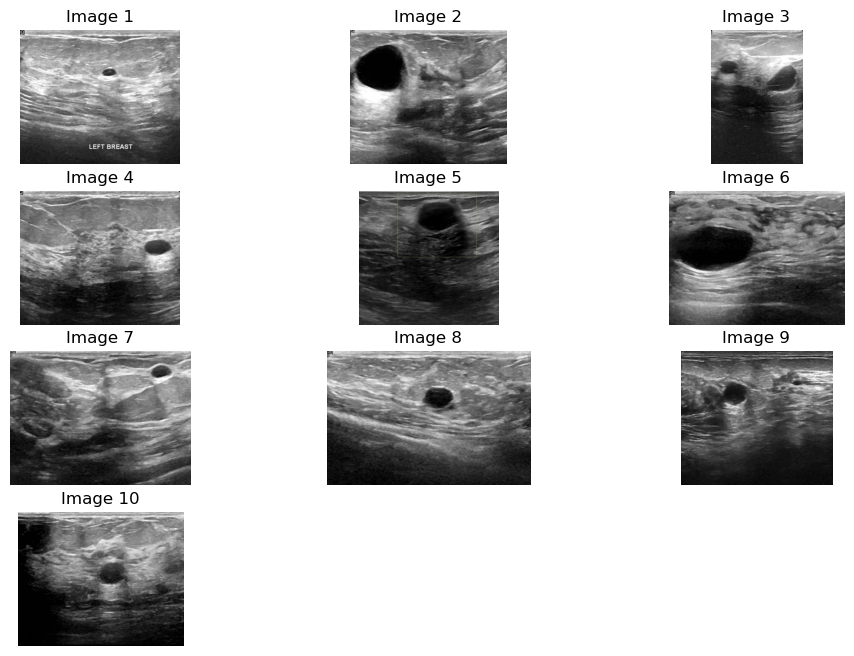

In [19]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Set the directory containing the images
image_dir = r"C:\Research\IOU\Dataset_BUSI_with_GT\image"

# Get a list of all image files in the directory
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

# Create a list to store the images
images = []

# Load the first 10 images
for i, image_file in enumerate(image_files):
    if i >= 10:
        break
    image_path = os.path.join(image_dir, image_file)
    image = Image.open(image_path)
    image_array = np.array(image)
    images.append(image_array)

# Determine the number of rows and columns for the subplot
num_images = len(images)
num_rows = int(np.ceil(np.sqrt(num_images)))
num_cols = int(np.ceil(num_images / num_rows))

# Create a figure with subplots
plt.figure(figsize=(12, 8))
for i, image in enumerate(images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Image {i+1}')

plt.show()